In [10]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, Dropout,MaxPool2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from utils.load_datasets import load_classification_dataset



In [11]:
X_train, y_train, X_test, y_test, class_names = load_classification_dataset()

X_train.shape



(5712, 150, 150, 3)

In [ ]:
X_test.shape

(1311, 150, 150, 3)

In [12]:
# Normalizing the data
X_train = X_train/255.0
X_test = X_test/255.0


In [4]:
# Splitting 20% of the training data for validation

X_train_, X_val, y_train_, y_val = train_test_split(X_train,y_train, test_size=0.2, random_state=42)


In [13]:
AlexNet = Sequential()

AlexNet.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding="same", input_shape=(150, 150, 3), activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Conv2D(64, (5, 5), padding="same", activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Conv2D(128, (3, 3), padding="same", activation="relu"))

AlexNet.add(Conv2D(128, (3, 3), padding="same", activation="relu"))

AlexNet.add(Conv2D(64, (3, 3), padding="same", activation="relu"))

AlexNet.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))

AlexNet.add(Flatten())

AlexNet.add(Dense(128, activation="relu"))

AlexNet.add(Dropout(0.3))

AlexNet.add(Dense(64, activation="relu"))

AlexNet.add(Dropout(0.3))

AlexNet.add(Dense(4, activation="softmax"))

e:\brain-tumor-classification-segmentation\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
#add  compile

AlexNet.compile(optimizer= 'adam',
                loss=keras.losses.sparse_categorical_crossentropy, 
                metrics=['accuracy']
                )

In [15]:
# Define callbacks for early stopping and model checkpointing

early_stopping = EarlyStopping(monitor='val_loss', patience=10,    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    './checkpoints/classification/alex_best_model.h5',       
    monitor='val_loss',    
    save_best_only=True
)

In [16]:
# Training the model

history =AlexNet.fit(X_train_,y_train_,epochs= 10, validation_data=(X_val, y_val), batch_size=32,
                 callbacks=[early_stopping, model_checkpoint])

Epoch 1/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5769 - loss: 0.9628

143/143 ━━━━━━━━━━━━━━━━━━━━ 392s 3s/step - accuracy: 0.5769 - loss: 0.9628 - val_accuracy: 0.7585 - val_loss: 0.6135
Epoch 2/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7884 - loss: 0.5543

143/143 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.7884 - loss: 0.5543 - val_accuracy: 0.8513 - val_loss: 0.4162
Epoch 3/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8667 - loss: 0.3988

143/143 ━━━━━━━━━━━━━━━━━━━━ 323s 2s/step - accuracy: 0.8667 - loss: 0.3988 - val_accuracy: 0.8819 - val_loss: 0.3722
Epoch 4/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8844 - loss: 0.3341

143/143 ━━━━━━━━━━━━━━━━━━━━ 318s 2s/step - accuracy: 0.8844 - loss: 0.3341 - val_accuracy: 0.8950 - val_loss: 0.2948
Epoch 5/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9068 - loss: 0.2870

143/143 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9068 - loss: 0.2870 - val_accuracy: 0.8915 - val_loss: 0.2748
Epoch 6/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9133 - loss: 0.2557

143/143 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9133 - loss: 0.2557 - val_accuracy: 0.9029 - val_loss: 0.2507
Epoch 7/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.9286 - loss: 0.2103 - val_accuracy: 0.9011 - val_loss: 0.2984
Epoch 8/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 321s 2s/step - accuracy: 0.9365 - loss: 0.1871 - val_accuracy: 0.9151 - val_loss: 0.2521
Epoch 9/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9407 - loss: 0.1663

143/143 ━━━━━━━━━━━━━━━━━━━━ 338s 2s/step - accuracy: 0.9407 - loss: 0.1663 - val_accuracy: 0.9204 - val_loss: 0.2295
Epoch 10/10
143/143 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.9488 - loss: 0.1471 - val_accuracy: 0.9099 - val_loss: 0.2487


36/36 - 17s - 483ms/step - accuracy: 0.9204 - loss: 0.2295


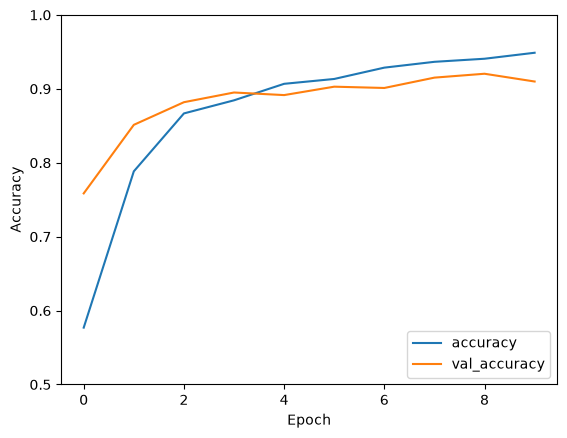

In [17]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = AlexNet.evaluate(X_val,  y_val, verbose=2)